## APhys Group Meeting, 6.5.2026

Flow speeds through constriction, comparing center and boundaries.

In [1]:
# imports
import ewgreaders as ewg
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from glob import glob
from tqdm.notebook import tqdm

### LZC v. LZW v. LZE

107-130 m depth range, February.

In [11]:
lake = 'Zug'
year = '2026'
date = '20260409'

loc_c = 'LZC'
sid_c = '16549'

loc_w = 'LZW'
sid_w = '16576'

loc_e = 'LZE'
sid_e = '23656'

bathy = xr.open_dataset(f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/bathymetry.nc')

In [12]:
areader = ewg.adcp_reader.ADCPReader(lake, year, date, loc_c, sid_c)
ds_c = areader.load()

areader = ewg.adcp_reader.ADCPReader(lake, year, date, loc_w, sid_w)
ds_w = areader.load()

areader = ewg.adcp_reader.ADCPReader(lake, year, date, loc_e, sid_e)
ds_e = areader.load()

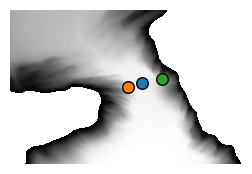

In [19]:
bathy_sel = bathy.sel(xsc=slice(2678500, 2681300), ysc=slice(1217500, 1220000))

fig, ax = plt.subplots(figsize=(3, 2))

im = ax.pcolormesh(bathy_sel['xsc'], bathy_sel['ysc'], bathy_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)

ax.scatter(ds_c.attrs['xsc'] + 2e6, ds_c.attrs['ysc'] + 1e6, s=70, c='tab:blue', edgecolor='black')
ax.scatter(ds_w.attrs['xsc'] + 2e6, ds_w.attrs['ysc'] + 1e6, s=70, c='tab:orange', edgecolor='black')
ax.scatter(ds_e.attrs['xsc'] + 2e6, ds_e.attrs['ysc'] + 1e6, s=70, c='tab:green', edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../../gallery/aphys/2026_05_06/map.svg', bbox_inches='tight')
plt.show()

In [20]:
deploy = pd.to_datetime('2026-02-05')
retrieve = pd.to_datetime('2026-04-09')
t_start = deploy + pd.Timedelta(days=1)
#t_end = retrieve - pd.Timedelta(days=1)
t_end = ds_e.time.values[-1]

z_max = 130
z_min = 107

ds_c = ds_c.sel(time=slice(t_start, t_end), depth=slice(z_max, z_min))
ds_w = ds_w.sel(time=slice(t_start, t_end), depth=slice(z_max, z_min))
ds_e = ds_e.sel(time=slice(t_start, t_end), depth=slice(z_max, z_min))

# shared time axis as mean of each instruments times
time_shared = np.mean([ ds_c.time.values.astype('int64'),  ds_w.time.values.astype('int64'), ds_e.time.values.astype('int64')], axis=0).astype('datetime64[ns]')
ds_c = ds_c.assign_coords(time=time_shared)
ds_w = ds_w.assign_coords(time=time_shared)
ds_e = ds_e.assign_coords(time=time_shared)

#### Flow speed

Depth average after speed calculation.  Do not get cancelation of different direction velocities.


In [21]:
# horizontal flow speed
uc = ds_c.vel.sel(dir='E')
vc = ds_c.vel.sel(dir='N')
speed_c = np.sqrt(uc**2 + vc**2).mean(dim='depth')

uw = ds_w.vel.sel(dir='E')
vw = ds_w.vel.sel(dir='N')
speed_w = np.sqrt(uw**2 + vw**2).mean(dim='depth')

ue = ds_e.vel.sel(dir='E')
ve = ds_e.vel.sel(dir='N')
speed_e = np.sqrt(ue**2 + ve**2).mean(dim='depth')

# 1-hour rolling average
window = 6
sc_ra = speed_c.rolling(time=window, center=True).mean()
sw_ra = speed_w.rolling(time=window, center=True).mean()
se_ra = speed_e.rolling(time=window, center=True).mean()

# 1-day binned average
sc_da = speed_c.groupby("time.date").mean()
sw_da = speed_w.groupby("time.date").mean()
se_da = speed_e.groupby("time.date").mean()

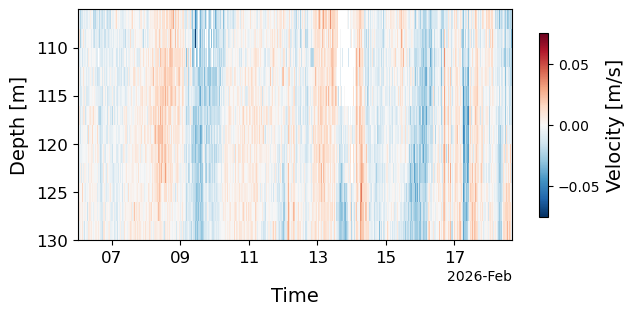

In [130]:
fig, ax = plt.subplots(figsize=(7, 3))

pc = vw.plot(x='time', y='depth', cmap='RdBu_r', cbar_kwargs={'label': 'Velocity [m/s]', 'shrink': 0.8}, ax=ax, rasterized=True)
pc.colorbar.ax.yaxis.label.set_size(14)

ax.set_xlabel('Time', fontsize=14, labelpad=15)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=5)
ax.set_title('')
ax.tick_params(axis='both', labelsize=12)

ax.invert_yaxis()
plt.savefig('../../gallery/aphys/2026_05_06/adcp_ts.svg', bbox_inches='tight')
plt.show()

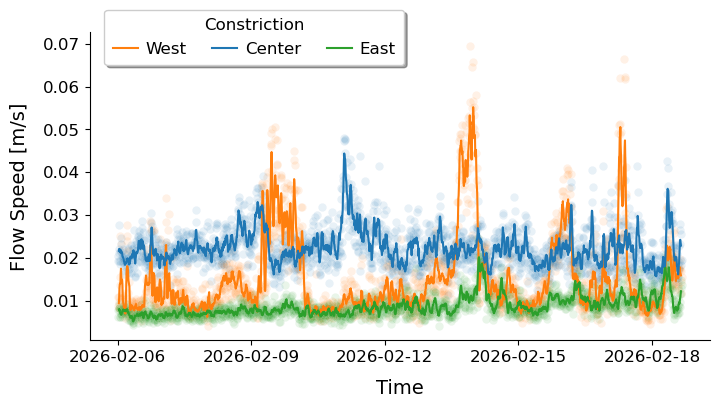

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(x=speed_w.time, y=speed_w, alpha=0.1, color='tab:orange', ax=ax)
sns.scatterplot(x=speed_c.time, y=speed_c, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=speed_e.time, y=speed_e, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=sw_ra.time, y=sw_ra, label='West', color='tab:orange', ax=ax)
sns.lineplot(x=sc_ra.time, y=sc_ra, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=se_ra.time, y=se_ra, label='East', color='tab:green', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=3, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0.01, 1.1),
          handlelength=1.5, handletextpad=0.5, columnspacing=1.5, borderpad=0.5)

plt.savefig('../../gallery/aphys/2026_05_06/flow_speed.svg', bbox_inches='tight')
plt.show()

In [24]:
# convert daily average flow speeds to pandas
ds_da = xr.concat([sc_da, sw_da, se_da], dim='location')
ds_da.coords['location'] = ['Center', 'West', 'East']
df_da = ds_da.to_dataframe(name='flow_speed').reset_index()

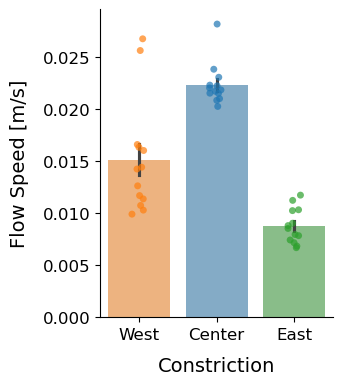

In [30]:
fig, ax = plt.subplots(figsize=(3, 4))
order = ['West', 'Center', 'East']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.stripplot(df_da, x='location', y='flow_speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.7, ax=ax)
sns.barplot(df_da, x='location', y='flow_speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.6, errorbar=('se', 1), ax=ax)

ax.set_xlabel('Constriction', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../../gallery/aphys/2026_05_06/flow_speed_da.svg', bbox_inches='tight')
plt.show()

#### Turbulence -- MicroCTD

In [27]:
lake = 'Zug'
year = '2026'
date = '20260213'

dpath_ctd = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/CTD/{date}/L2'
dpath_mctd = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/Level2'

fpaths_ctd = glob(f'{dpath_ctd}/*.nc')
fpaths_mctd = glob(f'{dpath_mctd}/*.nc')

In [28]:
eps_c, eps_w, eps_s = [], [], []

for fpath in fpaths_mctd:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)

    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')
    chi = xr.concat([ds['BINNED_Xi_T1'][mask], ds['BINNED_Xi_T2'][mask]], dim='sensor').mean(dim='sensor')
    K = xr.concat([ds['BINNED_KOsbornCox_T1'][mask], ds['BINNED_KOsbornCox_T2'][mask]], dim='sensor').mean(dim='sensor')

    # VMPS
    if 'DAT_095' in fpath:
        eps_s.append(eps)

    # VMPC
    elif 'DAT_093' in fpath:
        eps_c.append(eps)

    # VMPW
    elif 'DAT_094' in fpath:
        eps_w.append(eps)

eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')
eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
eps_w = xr.concat(eps_w, dim='BINNED_depth').sortby('BINNED_depth')

# 5 meter bins
bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_w = np.arange(0, eps_w['BINNED_depth'].max() + 5, 5)
eps_w_avg = eps_w.groupby_bins("BINNED_depth", bins_w).median()
bc_w = np.array([b.mid for b in eps_w_avg['BINNED_depth_bins'].values])

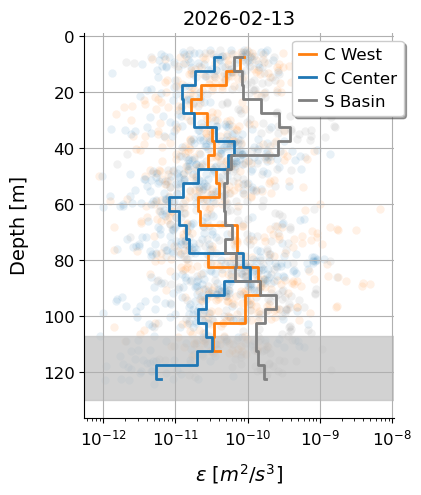

In [31]:
fig, ax = plt.subplots(figsize=(4, 5))

# epsilon
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color='tab:orange', alpha=0.1, ax=ax)
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color='tab:orange', linewidth=2, drawstyle="steps-mid", ax=ax, label='C West')

sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:blue', alpha=0.1, ax=ax)
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:blue', linewidth=2, drawstyle="steps-mid", ax=ax, label='C Center')

sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax)
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax, label='S Basin')

ax.axhspan(z_min, z_max, color='silver', alpha=0.7)

ax.set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('2026-02-13', fontsize=14)

ax.invert_yaxis()
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper center', bbox_to_anchor=(0.85, 1), 
          handlelength=1.0, handletextpad=0.5, columnspacing=1)

plt.savefig('../../gallery/aphys/2026_05_06/eps.svg', bbox_inches='tight')
plt.show()

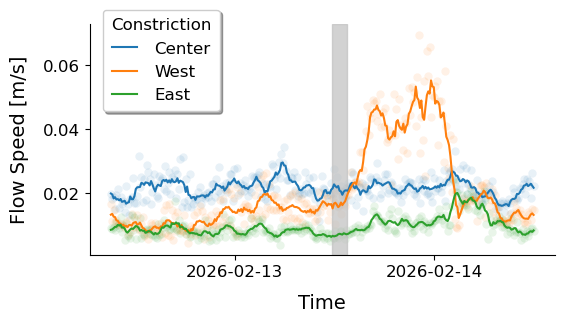

In [32]:
t0 = '2026-02-12 09:00:00'
tf = '2026-02-14 12:00:00'

sc_sel = speed_c.sel(time=slice(t0, tf))
sw_sel = speed_w.sel(time=slice(t0, tf))
se_sel = speed_e.sel(time=slice(t0, tf))

sc_ra_sel = sc_ra.sel(time=slice(t0, tf))
sw_ra_sel = sw_ra.sel(time=slice(t0, tf))
se_ra_sel = se_ra.sel(time=slice(t0, tf))

fig, ax = plt.subplots(figsize=(6, 3))

sns.scatterplot(x=sc_sel.time, y=sc_sel, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=sw_sel.time, y=sw_sel, alpha=0.1, color='tab:orange', ax=ax)
sns.scatterplot(x=se_sel.time, y=se_sel, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=sc_ra_sel.time, y=sc_ra_sel, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=sw_ra_sel.time, y=sw_ra_sel, label='West', color='tab:orange', ax=ax)
sns.lineplot(x=se_ra_sel.time, y=se_ra_sel, label='East', color='tab:green', ax=ax)

ax.axvspan(pd.to_datetime('2026-02-13 11:45:00'), pd.to_datetime('2026-02-13 13:30:00'), color='silver', alpha=0.7)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=1, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0.01, 1.1),
          handlelength=1.5, handletextpad=1, borderpad=0.5)

plt.savefig('../../gallery/aphys/2026_05_06/flow_speed_mctd.svg', bbox_inches='tight')
plt.show()

In [132]:
def TKE(ds, window=6):
    """
    Calculate turbulent kinetic energy (TKE).
    TKE = (u'^2 + v'^2 + w'^2) / 2

    Parameters
    ----------
    ds : xr.Dataset
        ADCP data.

    Returns
    -------
    tke : xr.DataArray
        Turbulent kinetic energy timeseries as function of depth.
    tke : 
    """
    u = ds.vel.sel(dir='E')
    v = ds.vel.sel(dir='N')
    w = ds.vel.sel(dir='U')

    # calculate velocity perturbations
    u_prime = u - u.rolling(time=window, center=True).mean()
    v_prime = v - v.rolling(time=window, center=True).mean()
    w_prime = w - w.rolling(time=window, center=True).mean()

    tke = 0.5 * (u_prime**2 + v_prime**2 + w_prime**2)

    return tke.drop_vars('dir').rename('tke')

In [136]:
tke_c = TKE(ds_c.sel(time=slice(t0, tf))).mean(dim='depth')
tke_w = TKE(ds_w.sel(time=slice(t0, tf))).mean(dim='depth')
tke_e = TKE(ds_e.sel(time=slice(t0, tf))).mean(dim='depth')

window = 6
tke_c_ra = tke_c.rolling(time=window, center=True).mean()
tke_w_ra = tke_w.rolling(time=window, center=True).mean()
tke_e_ra = tke_e.rolling(time=window, center=True).mean()

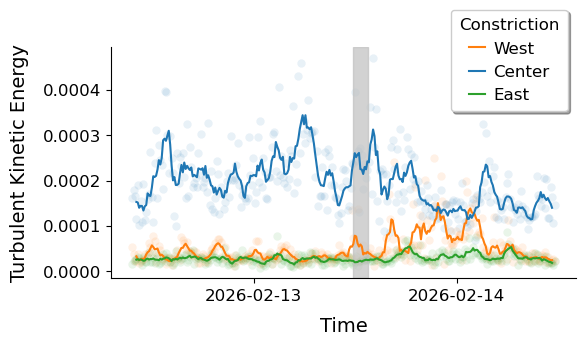

In [164]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.scatterplot(x=tke_w.time, y=tke_w, alpha=0.1, color='tab:orange', ax=ax)
sns.scatterplot(x=tke_c.time, y=tke_c, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=tke_e.time, y=tke_e, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=tke_w_ra.time, y=tke_w_ra, label='West', color='tab:orange', ax=ax)
sns.lineplot(x=tke_c_ra.time, y=tke_c_ra, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=tke_e_ra.time, y=tke_e_ra, label='East', color='tab:green', ax=ax)

ax.axvspan(pd.to_datetime('2026-02-13 11:45:00'), pd.to_datetime('2026-02-13 13:30:00'), color='silver', alpha=0.7)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Turbulent Kinetic Energy', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=1, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper right', bbox_to_anchor=(1, 1.2),
          handlelength=1, handletextpad=0.5, borderpad=0.5, columnspacing=0.5)

plt.savefig('../../gallery/aphys/2026_05_06/tke.svg', bbox_inches='tight')
plt.show()

#### Turbulence CTD

In [33]:
def rolling_average(data, depth, ra_window):
    """
    Compute rolling average.

    Parameters
    ----------
    data : array_like
        Data variable to compute rolling average of.
    depth : array_like
        Depth below water surface.
    ra_window : float
        Depth window for rolling average.

    Returns
    -------
    data_ra : xr.DataArray
        Rolling average of data.
    """
    data_ra = []
    for d in depth:
        mask = (depth >= d - (ra_window/2)) & (depth <= d + (ra_window/2))
        data_ra.append(np.mean(data[mask]))


    return xr.DataArray(data_ra, dims=data.dims, coords=data.coords, name=data.name)

def order_profile(var, descending):
    """
    Order profile.  Stable so repeat values maintain original order.

    Parameters
    ----------
    var : xr.DataArray
        Variable profile to sort.
    depth : xr.DataArray
        Depth below water surface, increasing.
    descending : bool
        True if var decreases with depth, False if var increases with depth.
    """
    if descending:
        s = -1
    else:
        s = 1

    var_ascending = var*s
    idx = var_ascending.argsort(kind='mergesort').values
    var_sorted = var_ascending.isel(depth=idx)

    return var_sorted*s

In [34]:
lake = 'Zug'
year = '2026'
date = '20260213'

di = ewg.get_data_index(lake, 'ctd')
di_sel = di[di['date'] == '2026-02-13']
di_sel

,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
271,Zug,2026-02-13,11:15,VMPN,679254,220426,sea&sun,1807,K2131606_1
272,Zug,2026-02-13,12:01,VMPN,679137,220310,sea&sun,1807,K2131606_2
273,Zug,2026-02-13,12:19,VMPC,680116,218739,sea&sun,1807,K2131606_3
274,Zug,2026-02-13,13:20,VMPC,680105,218758,sea&sun,1807,K2131606_4
275,Zug,2026-02-13,13:38,VMPW,679914,218749,sea&sun,1807,K2131606_5
276,Zug,2026-02-13,14:23,VMPW,679962,218752,sea&sun,1807,K2131606_6
277,Zug,2026-02-13,14:38,P6E,680299,218827,sea&sun,1807,K2131606_7
278,Zug,2026-02-13,15:01,VMPS,680436,216858,sea&sun,1807,K2131606_8


In [95]:
data = []
res = []
for _, p in tqdm(di_sel.iterrows(), total=len(di_sel)):
    if p.profile_loc in ['VMPC', 'VMPW', 'P6E', 'VMPS']:
        ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
        ds = ctdreader.load()
        ds_sel = ds.sel(depth=slice(z_min, z_max))

        rho_ra = rolling_average(ds_sel['rho'], ds_sel['depth'], 1)
        rho_sorted = order_profile(rho_ra, False)
        thorpe_displacement = (ds_sel['depth'] - rho_sorted['depth'].values).rename('thorpe_displacement')
        L_thorpe = np.sqrt((thorpe_displacement ** 2).mean().item())

        temp_sorted = order_profile(ds_sel['temp'], True)
        temp_displacement = (ds_sel['depth'] - temp_sorted['depth'].values).rename('temp_displacement')
        L_temp = np.sqrt((temp_displacement ** 2).mean().item())

        # all profiles reach anoxia
        mask_anoxic = ds_sel['do2_conc'] > ds_sel['do2_conc'].min() + 0.02
        do_sorted = order_profile(ds_sel['do2_conc'][mask_anoxic], True)
        do_displacement = (ds_sel['depth'][mask_anoxic] - do_sorted['depth'].values).rename('do_displacement')
        L_do = np.sqrt((do_displacement ** 2).mean().item())

        dat = pd.DataFrame({
            'depth': ds_sel['depth'],
            'temp': ds_sel['temp'],
            'rho_ra': rho_ra
        })
        dat[['profile_loc', 'time']] = p.profile_loc, p.time
        data.append(dat)
        
        res.append({
            'profile_loc': p.profile_loc,
            'time': p.time,
            'L_thorpe': L_thorpe,
            'L_temp': L_temp,
            'L_do': L_do
        })

data = pd.concat(data, ignore_index=True)
res = pd.DataFrame(res)

  0%|          | 0/8 [00:00<?, ?it/s]

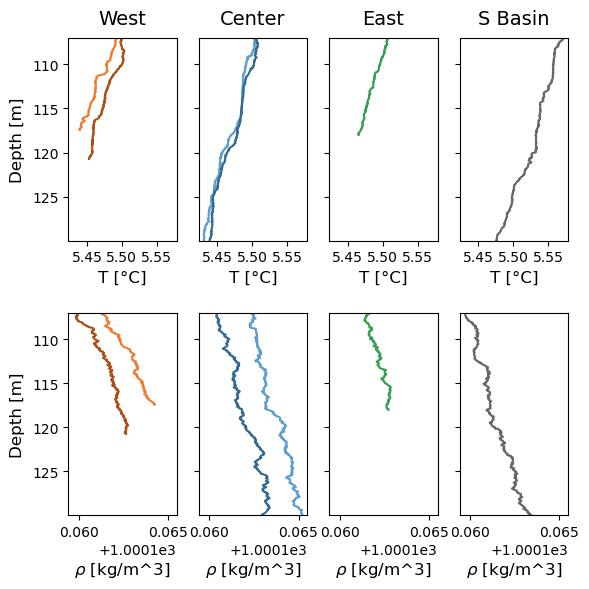

In [109]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(6, 6), sharey=True, sharex='row')
order = ['VMPW', 'VMPC', 'P6E']

# temperature
sns.lineplot(data.query("profile_loc == 'VMPW'"), x='temp', y='depth', orient='y', hue='time', palette='Oranges_d', ax=ax[0, 0], legend=False)
sns.lineplot(data.query("profile_loc == 'VMPC'"), x='temp', y='depth', orient='y', hue='time', palette='Blues_d', ax=ax[0, 1], legend=False)
sns.lineplot(data.query("profile_loc == 'P6E'"), x='temp', y='depth', orient='y', hue='time', palette='Greens_d', ax=ax[0, 2], legend=False)
sns.lineplot(data.query("profile_loc == 'VMPS'"), x='temp', y='depth', orient='y', hue='time', palette='Grays_d', ax=ax[0, 3], legend=False)

# density
sns.lineplot(data.query("profile_loc == 'VMPW'"), x='rho_ra', y='depth', orient='y', hue='time', palette='Oranges_d', ax=ax[1, 0], legend=False)
sns.lineplot(data.query("profile_loc == 'VMPC'"), x='rho_ra', y='depth', orient='y', hue='time', palette='Blues_d', ax=ax[1, 1], legend=False)
sns.lineplot(data.query("profile_loc == 'P6E'"), x='rho_ra', y='depth', orient='y', hue='time', palette='Greens_d', ax=ax[1, 2], legend=False)
sns.lineplot(data.query("profile_loc == 'VMPS'"), x='rho_ra', y='depth', orient='y', hue='time', palette='Grays_d', ax=ax[1, 3], legend=False)

ax[0, 0].set_ylabel('Depth [m]', fontsize=12, labelpad=5)
ax[1, 0].set_ylabel('Depth [m]', fontsize=12, labelpad=5)
ax[0, 0].set_title('West', fontsize=14, pad=10)
ax[0, 1].set_title('Center', fontsize=14, pad=10)
ax[0, 2].set_title('East', fontsize=14, pad=10)
ax[0, 3].set_title('S Basin', fontsize=14, pad=10)

for i in range(ax.shape[1]):
    ax[0, i].set_xlabel('T [°C]', fontsize=12)
    ax[1, i].set_xlabel(r'$\rho$ [kg/m^3]', fontsize=12, labelpad=15)

ax[0, 0].set_ylim(data.depth.min(), data.depth.max())
ax[0, 0].invert_yaxis()

plt.tight_layout(w_pad=0, h_pad=2)
plt.savefig('../../gallery/aphys/2026_05_06/ctd.svg', bbox_inches='tight')
plt.show()

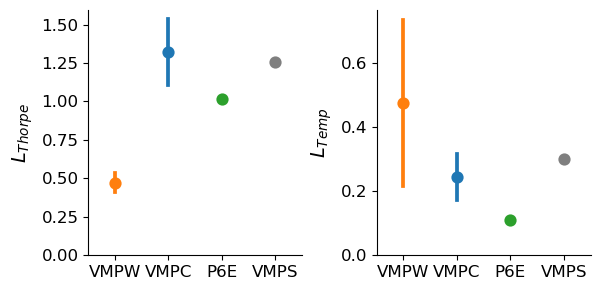

In [102]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
order = ['VMPW', 'VMPC', 'P6E', 'VMPS']
palette = ['tab:orange', 'tab:blue', 'tab:green', 'tab:gray']

sns.pointplot(res, x='profile_loc', y='L_thorpe', order=order, hue='profile_loc', hue_order=order, palette=palette, 
              errorbar=('se', 1), ax=ax[0])

sns.pointplot(res, x='profile_loc', y='L_temp', order=order, hue='profile_loc', hue_order=order, palette=palette, 
              errorbar=('se', 1), ax=ax[1])


ax[0].set_ylabel(r'$L_{Thorpe}$', fontsize=14, labelpad=5)
ax[1].set_ylabel(r'$L_{Temp}$', fontsize=14, labelpad=5)

for i in range(len(ax)):
    ax[i].set_xlabel('')
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].set_ylim(0, None)

plt.tight_layout(w_pad=0.5)
plt.savefig('../../gallery/aphys/2026_05_06/thorpe.svg', bbox_inches='tight')
plt.show()

### Workspace

In [320]:
# horizontal flow speed
uc = ds_c.vel.sel(dir='E').mean(dim='depth')
vc = ds_c.vel.sel(dir='N').mean(dim='depth')
speed_c = np.sqrt(uc**2 + vc**2).rename('speed')

uw = ds_w.vel.sel(dir='E').mean(dim='depth')
vw = ds_w.vel.sel(dir='N').mean(dim='depth')
speed_w = np.sqrt(uw**2 + vw**2).rename('speed')

ue = ds_e.vel.sel(dir='E').mean(dim='depth')
ve = ds_e.vel.sel(dir='N').mean(dim='depth')
speed_e = np.sqrt(ue**2 + ve**2).rename('speed')

# 1-hour rolling average
window = 6
sc_ra = speed_c.rolling(time=window, center=True).mean()
sw_ra = speed_w.rolling(time=window, center=True).mean()
se_ra = speed_e.rolling(time=window, center=True).mean()

# 1-day binned average
sc_da = speed_c.groupby("time.date").mean()
sw_da = speed_w.groupby("time.date").mean()
se_da = speed_e.groupby("time.date").mean()

#### Timeseries

LZC v. LZW v. LZE, horizontal speed (1-hour rolling average)

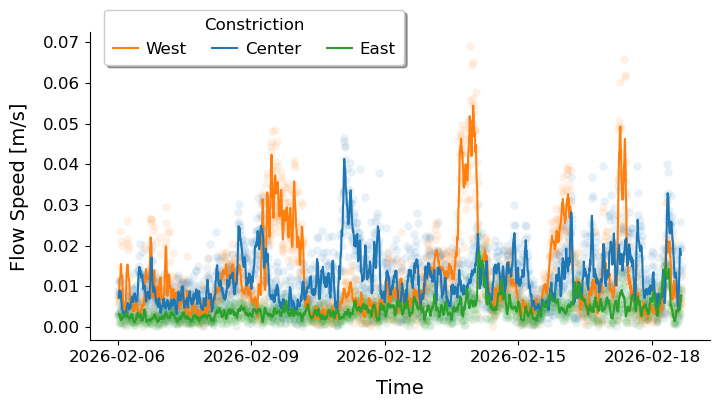

In [321]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(x=speed_w.time, y=speed_w, alpha=0.1, color='tab:orange', ax=ax)
sns.scatterplot(x=speed_c.time, y=speed_c, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=speed_e.time, y=speed_e, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=sw_ra.time, y=sw_ra, label='West', color='tab:orange', ax=ax)
sns.lineplot(x=sc_ra.time, y=sc_ra, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=se_ra.time, y=se_ra, label='East', color='tab:green', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=3, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0.01, 1.1),
          handlelength=1.5, handletextpad=0.5, columnspacing=1.5, borderpad=0.5)

plt.show()

#### Daily binned average

LZC v. LZW v. LZE, for statistical testing

In [322]:
# convert daily average flow speeds to pandas
ds_da = xr.concat([sc_da, sw_da, se_da], dim='location')
ds_da.coords['location'] = ['Center', 'West', 'East']
df_da = ds_da.to_dataframe(name='flow_speed').reset_index()

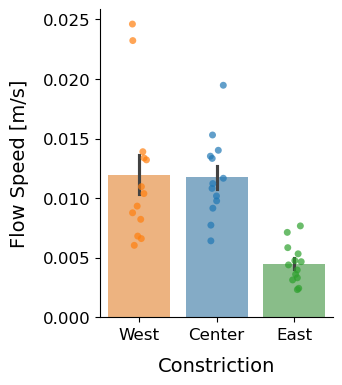

In [323]:
fig, ax = plt.subplots(figsize=(3, 4))
order = ['West', 'Center', 'East']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.stripplot(df_da, x='location', y='flow_speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.7, ax=ax)
sns.barplot(df_da, x='location', y='flow_speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.6, errorbar=('se', 1), ax=ax)

ax.set_xlabel('Constriction', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.show()

#### Flow angle

In [324]:
def flow_angle(ds):
    """
    Calculate angle of flow from ADCP velocity data.
    Map {'E', 'N', 'W', 'S'} to angles {0°, 90°, 180/-180°, -90°}.

    Parameters
    ----------
    ds : xr.DataArray
        ADCP data.

    Returns
    -------
    flow_ang : xr.DataArray
        Flow angle timeseries [°].
    """
    u = ds.vel.sel(dir='E').mean(dim='depth')
    v = ds.vel.sel(dir='N').mean(dim='depth')

    flow_ang = np.rad2deg(np.arctan2(v, u))

    return flow_ang.rename('angle')


def flow_angle_to_df(ds, location):
    df = ds.to_dataframe().reset_index()
    df['angle_shifted'] = [a + 180 if a < 0 else a for a in df.angle]
    df['angle_from_north'] = df['angle_shifted'] - 90
    df['location'] = location
    df['direction'] = ['N' if a > 0 else 'S' for a in df.angle]

    return df

In [325]:
ang_c = flow_angle(ds_c)
ang_w = flow_angle(ds_w)
ang_e = flow_angle(ds_e)

# convert to dataframe
df_ang_c = flow_angle_to_df(ang_c, "Center")
df_ang_w = flow_angle_to_df(ang_w, 'West')
df_ang_e = flow_angle_to_df(ang_e, 'East')
df_ang = pd.concat([df_ang_c, df_ang_w, df_ang_e], ignore_index=True)

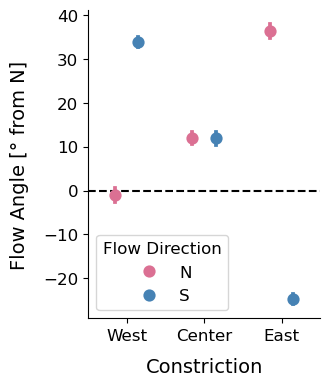

In [326]:
fig, ax = plt.subplots(figsize=(3, 4))
loc_order = ['West', 'Center', 'East']
dir_order = ['N', 'S']
palette = ['palevioletred', 'steelblue']

ax.axhline(0, color='black', linestyle='--')
sns.pointplot(df_ang, x='location', y='angle_from_north', order=order, hue='direction', hue_order=dir_order, palette=palette, 
              linestyle='none', dodge=0.3, errorbar=('se', 1), ax=ax)

ax.set_xlabel('Constriction', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Angle [° from N]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(title='Flow Direction', fontsize=12, title_fontsize=12)

plt.show()

#### Flow angle and speed

In [328]:
df_c = pd.merge(df_ang_c, speed_c.to_dataframe(), on=['time', 'serial_id'])
df_w = pd.merge(df_ang_w, speed_w.to_dataframe(), on=['time', 'serial_id'])
df_e = pd.merge(df_ang_e, speed_e.to_dataframe(), on=['time', 'serial_id'])

<Axes: xlabel='angle_from_north', ylabel='speed'>

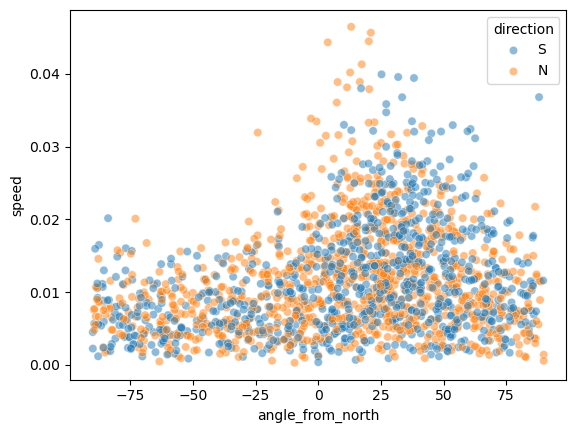

In [335]:
sns.scatterplot(df_c, x='angle_from_north', y='speed', hue='direction', alpha=0.5)

<Axes: xlabel='angle_from_north', ylabel='speed'>

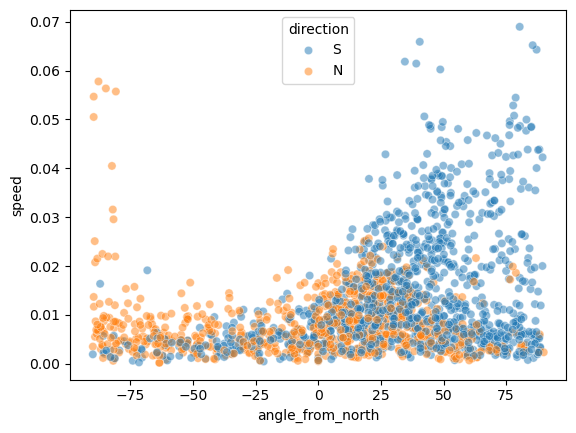

In [337]:
sns.scatterplot(df_w, x='angle_from_north', y='speed', hue='direction', alpha=0.5)

<Axes: xlabel='angle_from_north', ylabel='speed'>

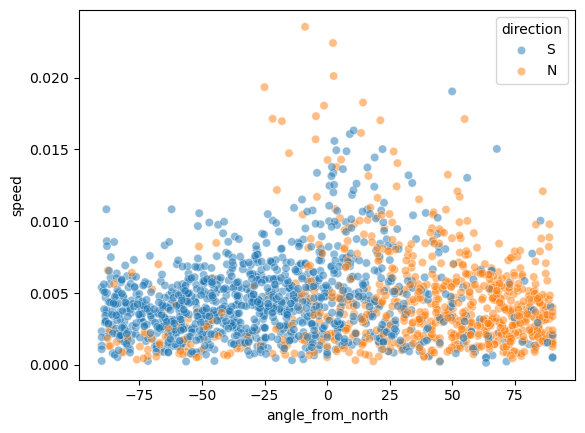

In [338]:
sns.scatterplot(df_e, x='angle_from_north', y='speed', hue='direction', alpha=0.5)

In [306]:
ang_c

<xarray.DataArray 'angle' (time: 1824)> Size: 7kB
array([-88.21008 , -81.42228 , -29.224417, ..., -81.240295, -71.25196 ,
       -76.12629 ], shape=(1824,), dtype=float32)
Coordinates:
    serial_id  <U5 20B '16549'
  * time       (time) datetime64[ns] 15kB 2026-02-06T00:06:52.370474240 ... 2...

<Axes: xlabel='angle', ylabel='vel'>

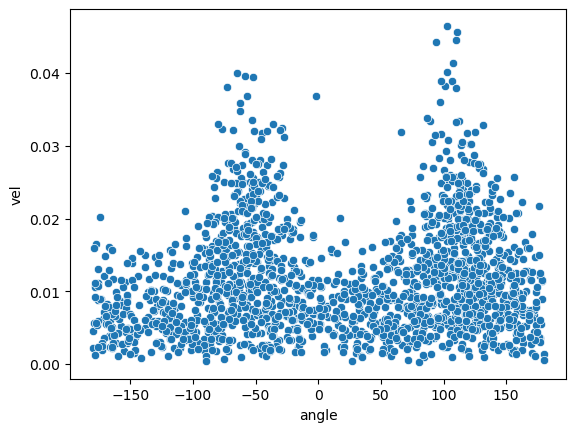

In [ ]:
sns.scatterplot(x=ang_c, y=speed_c)

<Axes: xlabel='angle', ylabel='vel'>

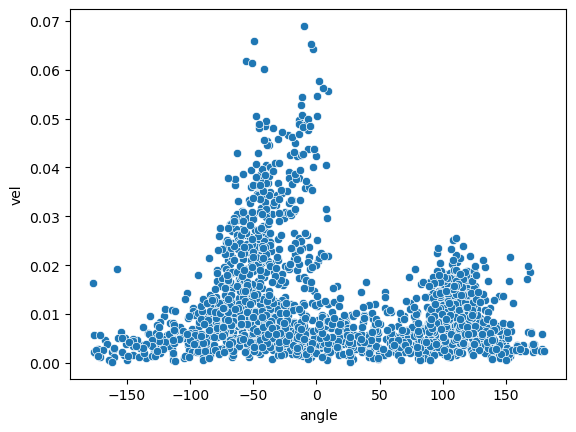

In [308]:
sns.scatterplot(x=ang_w, y=speed_w)

<Axes: xlabel='angle', ylabel='vel'>

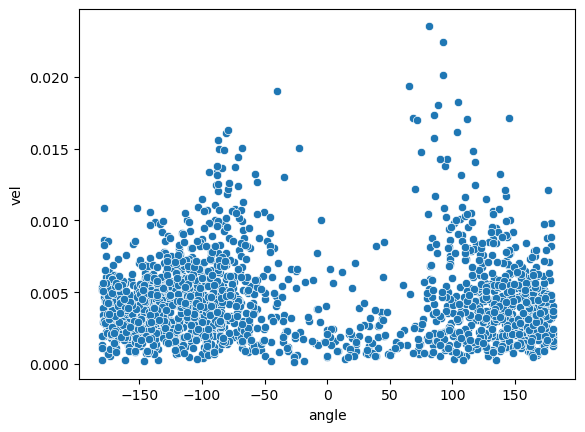

In [309]:
sns.scatterplot(x=ang_e, y=speed_e)

In [310]:
ang_e.max()

<xarray.DataArray 'angle' ()> Size: 8B
array(180.)
Coordinates:
    serial_id  <U5 20B '23656'

#### Turbulence

In [ ]:
def TKE(ds, window=6):
    """
    Calculate turbulent kinetic energy (TKE).
    TKE = (u'^2 + v'^2 + w'^2) / 2

    Parameters
    ----------
    ds : xr.Dataset
        ADCP data.

    Returns
    -------
    tke : xr.DataArray
        Turbulent kinetic energy timeseries as function of depth.
    tke : 
    """
    u = ds.vel.sel(dir='E')
    v = ds.vel.sel(dir='N')
    w = ds.vel.sel(dir='U')

    u_ra = u.rolling(time=window, center=True).mean()
    v_ra = v.rolling(time=window, center=True).mean()
    w_ra = w.rolling(time=window, center=True).mean()

    # calculate velocity perturbations
    u_prime = u - u.mean(dim='time')
    v_prime = v - v.mean(dim='time')
    w_prime = w - w.mean(dim='time')

    tke = 0.5 * (u_prime**2 + v_prime**2 + w_prime**2)

    return tke.drop_vars('dir').rename('tke')

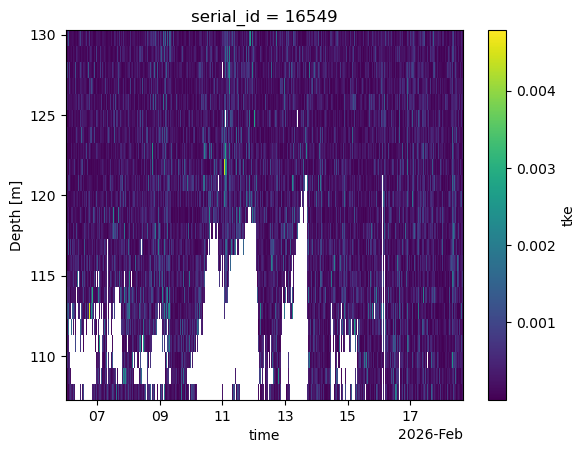

In [356]:
tke_c = ewg.efd.TKE(ds_c)
tke_c.plot()

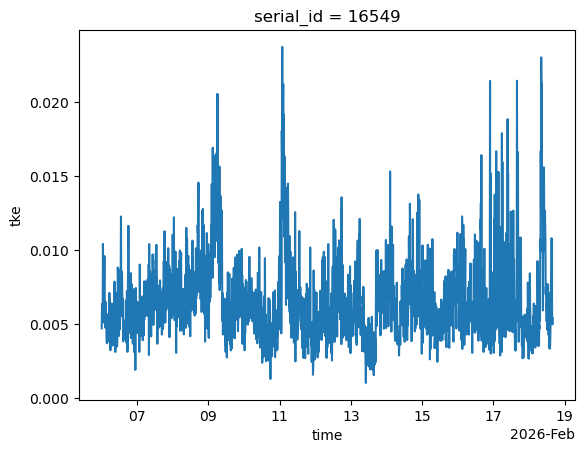

In [352]:
ewg.efd.TKE(ds_c).sum(dim='depth').plot()

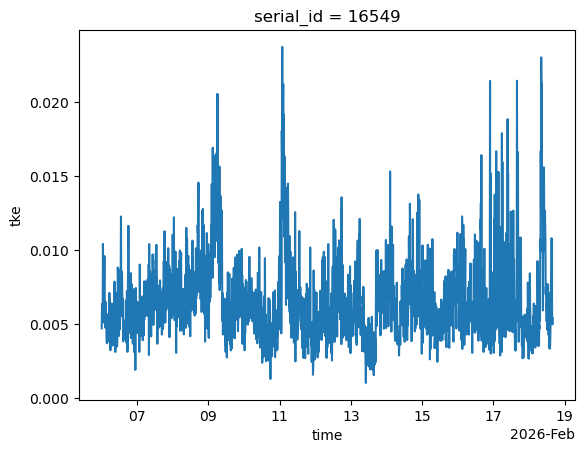

In [342]:
ewg.efd.TKE(ds_c).sum(dim='depth').plot()

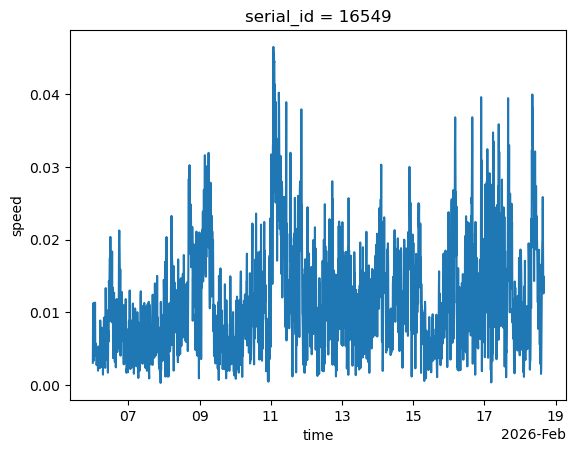

In [343]:
speed_c.plot()

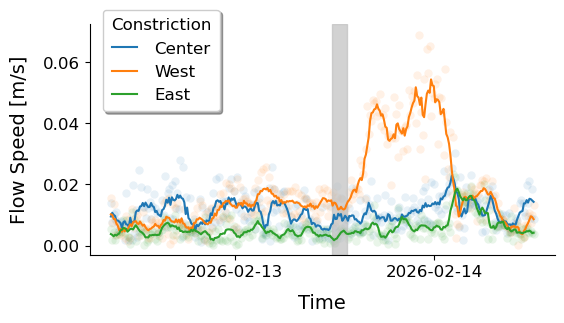

In [304]:
t0 = '2026-02-12 09:00:00'
tf = '2026-02-14 12:00:00'

sc_sel = speed_c.sel(time=slice(t0, tf))
sw_sel = speed_w.sel(time=slice(t0, tf))
se_sel = speed_e.sel(time=slice(t0, tf))

sc_ra_sel = sc_ra.sel(time=slice(t0, tf))
sw_ra_sel = sw_ra.sel(time=slice(t0, tf))
se_ra_sel = se_ra.sel(time=slice(t0, tf))

fig, ax = plt.subplots(figsize=(6, 3))

sns.scatterplot(x=sc_sel.time, y=sc_sel, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=sw_sel.time, y=sw_sel, alpha=0.1, color='tab:orange', ax=ax)
sns.scatterplot(x=se_sel.time, y=se_sel, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=sc_ra_sel.time, y=sc_ra_sel, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=sw_ra_sel.time, y=sw_ra_sel, label='West', color='tab:orange', ax=ax)
sns.lineplot(x=se_ra_sel.time, y=se_ra_sel, label='East', color='tab:green', ax=ax)

ax.axvspan(pd.to_datetime('2026-02-13 11:45:00'), pd.to_datetime('2026-02-13 13:30:00'), color='silver', alpha=0.7)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=1, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0.01, 1.1),
          handlelength=1.5, handletextpad=1, borderpad=0.5)

plt.show()

In [211]:
ang_c.where(ang_c > 0).mean().item(), ang_c.where(ang_c < 0).mean().item()

(102.01829528808594, -78.11572265625)

In [212]:
ang_w.where(ang_w > 0).mean().item(), ang_w.where(ang_w < 0).mean().item()

(88.96017456054688, -56.00461959838867)

In [213]:
ang_e.where(ang_e > 0).mean().item(), ang_e.where(ang_e < 0).mean().item()

(126.4020004272461, -114.70275115966797)

#### E-W & N-S components

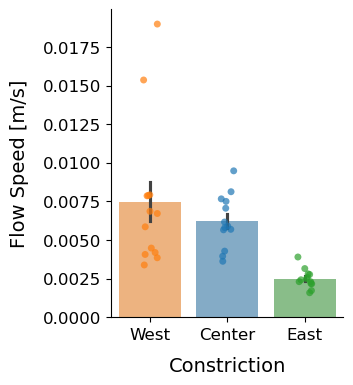

In [15]:
fig, ax = plt.subplots(figsize=(3, 4))
order = ['West', 'Center', 'East']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.stripplot(df_su_da, x='location', y='speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.7, ax=ax)
sns.barplot(df_su_da, x='location', y='speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.6, errorbar=('se', 1), ax=ax)

ax.set_xlabel('Constriction', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.show()

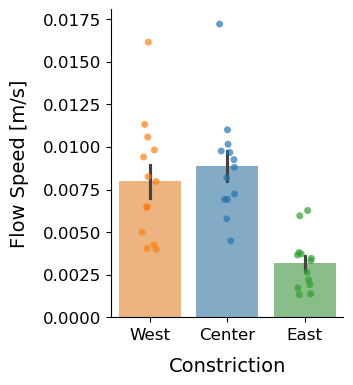

In [16]:
fig, ax = plt.subplots(figsize=(3, 4))
order = ['West', 'Center', 'East']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.stripplot(df_sv_da, x='location', y='speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.7, ax=ax)
sns.barplot(df_sv_da, x='location', y='speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.6, errorbar=('se', 1), ax=ax)

ax.set_xlabel('Constriction', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.show()

In [11]:
# 1-hour rolling average on speed components
window = 6
uc_ra = abs(uc).rolling(time=window, center=True).mean()
uw_ra = abs(uw).rolling(time=window, center=True).mean()
ue_ra = abs(ue).rolling(time=window, center=True).mean()

vc_ra = abs(vc).rolling(time=window, center=True).mean()
vw_ra = abs(vw).rolling(time=window, center=True).mean()
ve_ra = abs(ve).rolling(time=window, center=True).mean()

# 1-day binned average on speed components
uc_da = abs(uc).groupby("time.date").mean()
uw_da = abs(uw).groupby("time.date").mean()
ue_da = abs(ue).groupby("time.date").mean()

vc_da = abs(vc).groupby("time.date").mean()
vw_da = abs(vw).groupby("time.date").mean()
ve_da = abs(ve).groupby("time.date").mean()

In [12]:
ds_su_ra = xr.concat([uc_ra, uw_ra, ue_ra], dim='location')
ds_su_ra.coords['location'] = ['Center', 'West', 'East']
df_su_ra = ds_su_ra.to_dataframe(name='speed').reset_index()

ds_sv_ra = xr.concat([vc_ra, vw_ra, ve_ra], dim='location')
ds_sv_ra.coords['location'] = ['Center', 'West', 'East']
df_sv_ra = ds_sv_ra.to_dataframe(name='speed').reset_index()

df_suv_ra = pd.merge(df_su_ra, df_sv_ra, on=['location', 'time', 'serial_id'], suffixes=('_u', '_v'))

In [13]:
ds_su_da = xr.concat([uc_da, uw_da, ue_da], dim='location')
ds_su_da.coords['location'] = ['Center', 'West', 'East']
df_su_da = ds_su_da.to_dataframe(name='speed').reset_index()

ds_sv_da = xr.concat([vc_da, vw_da, ve_da], dim='location')
ds_sv_da.coords['location'] = ['Center', 'West', 'East']
df_sv_da = ds_sv_da.to_dataframe(name='speed').reset_index()

df_suv_da = pd.merge(df_su_da, df_sv_da, on=['location', 'date', 'serial_id'], suffixes=('_u', '_v'))

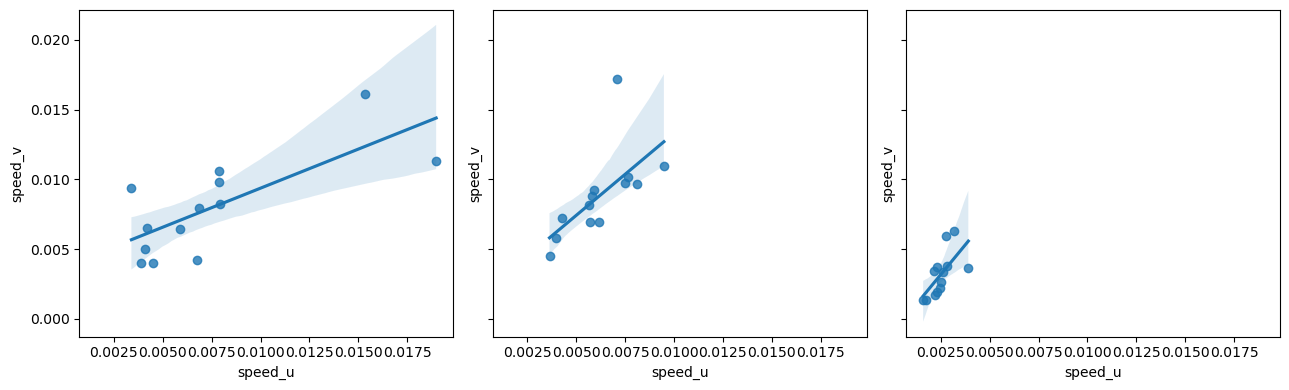

In [115]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4), sharey=True, sharex=True)

sns.regplot(df_suv_da.query("location == 'West'"), x='speed_u', y='speed_v', ax=ax[0])

sns.regplot(df_suv_da.query("location == 'Center'"), x='speed_u', y='speed_v', ax=ax[1])

sns.regplot(df_suv_da.query("location == 'East'"), x='speed_u', y='speed_v', ax=ax[2])

plt.tight_layout()
plt.show()

<Axes: xlabel='speed_u', ylabel='speed_v'>

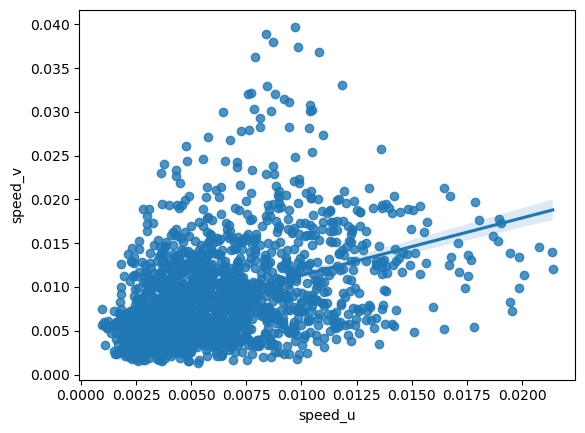

In [112]:
sns.regplot(df_suv_ra.query("location == 'Center'"), x='speed_u', y='speed_v')

<Axes: xlabel='speed_u', ylabel='speed_v'>

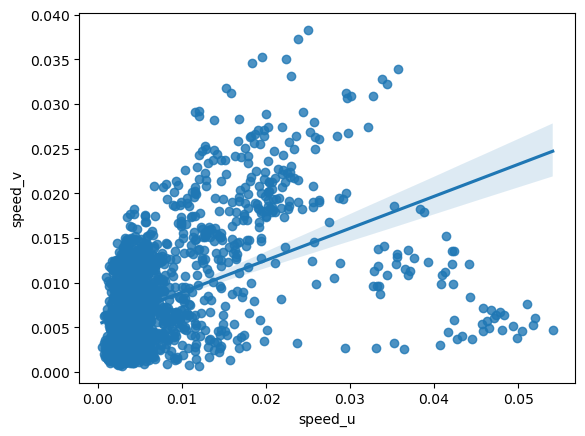

In [113]:
sns.regplot(df_suv_ra.query("location == 'West'"), x='speed_u', y='speed_v')

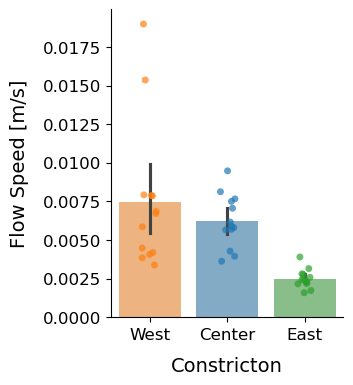

In [81]:
fig, ax = plt.subplots(figsize=(3, 4))
order = ['West', 'Center', 'East']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.stripplot(df_su_da, x='location', y='speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.7, ax=ax)
sns.barplot(df_su_da, x='location', y='speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.6, ax=ax)

ax.set_xlabel('Constricton', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.show()

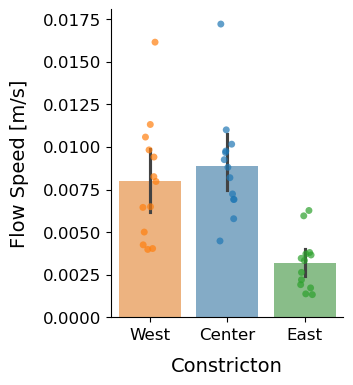

In [82]:
fig, ax = plt.subplots(figsize=(3, 4))
order = ['West', 'Center', 'East']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.stripplot(df_sv_da, x='location', y='speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.7, ax=ax)
sns.barplot(df_sv_da, x='location', y='speed', order=order, hue='location', hue_order=order, palette=palette, alpha=0.6, ax=ax)

ax.set_xlabel('Constricton', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.show()

In [86]:
df_suv_da

,location,date,dir,serial_id,speed
0,Center,2026-02-06,E,16549,0.003958
1,Center,2026-02-07,E,16549,0.003631
2,Center,2026-02-08,E,16549,0.005908
3,Center,2026-02-09,E,16549,0.005807
4,Center,2026-02-10,E,16549,0.005698
...,...,...,...,...,...
34,East,2026-02-14,N,23656,0.006269
35,East,2026-02-15,N,23656,0.003464
36,East,2026-02-16,N,23656,0.003661
37,East,2026-02-17,N,23656,0.003808


In [ ]:
fig, ax = plt.subplots()

sns.scatterplot(df_suv_da, x='')

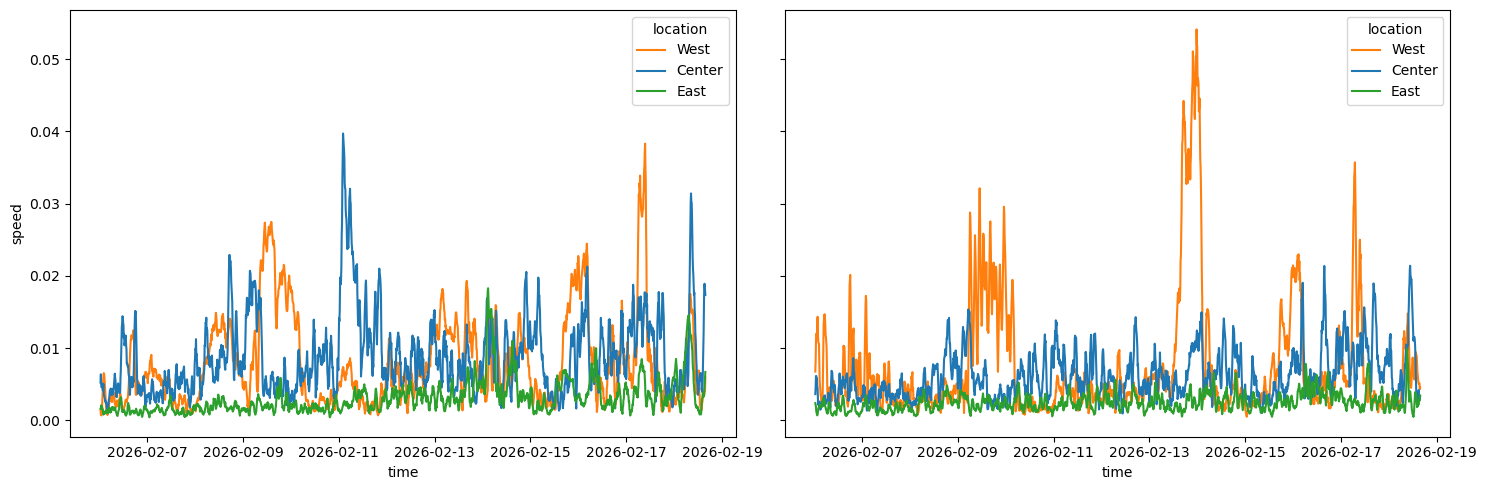

In [120]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), sharey=True)
order = ['West', 'Center', 'East']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.lineplot(df_sv_ra, x='time', y='speed', hue='location', hue_order=order, palette=palette, ax=ax[0])
sns.lineplot(df_su_ra, x='time', y='speed', hue='location', hue_order=order, palette=palette, ax=ax[1])

plt.tight_layout()
plt.show()

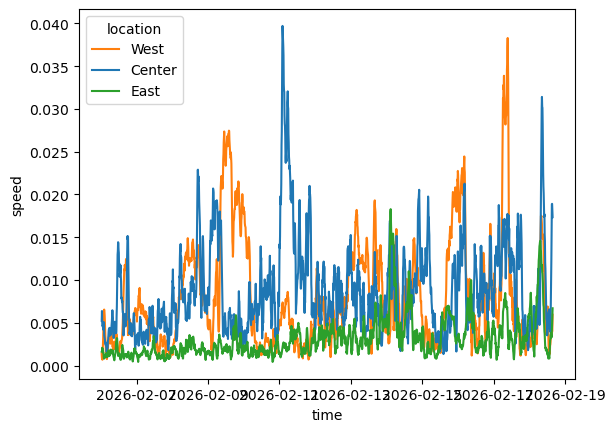

In [84]:
fig, ax = plt.subplots()
order = ['West', 'Center', 'East']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.lineplot(df_sv_ra, x='time', y='speed', hue='location', hue_order=order, palette=palette, ax=ax)

plt.show()

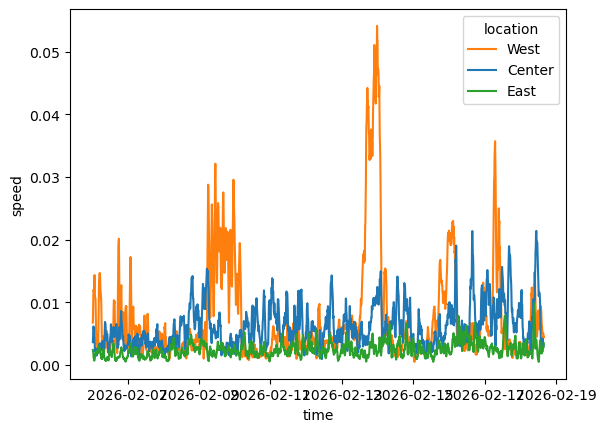

In [75]:
fig, ax = plt.subplots()
order = ['West', 'Center', 'East']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.lineplot(df_suv_ra.query("dir == 'E'"), x='time', y='speed', hue='location', hue_order=order, palette=palette, ax=ax)

plt.show()

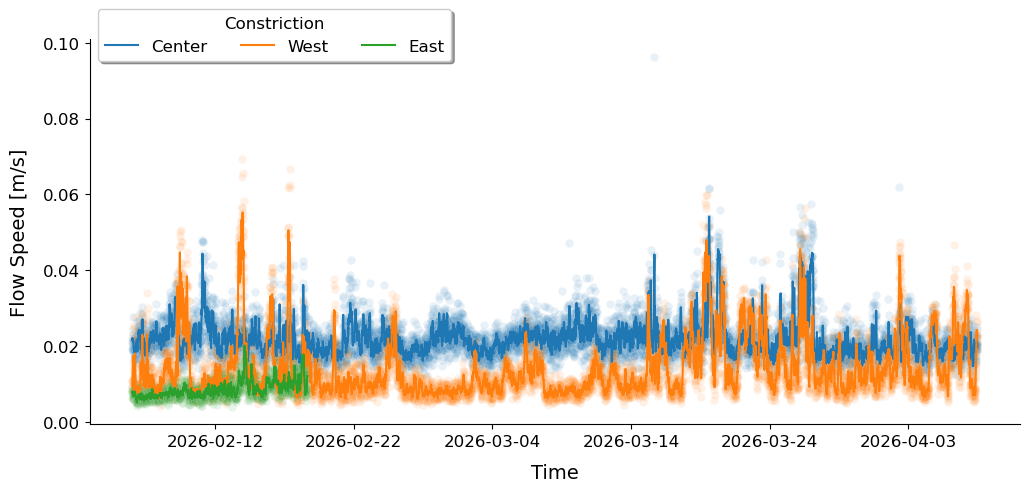

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.scatterplot(x=speed_c.time, y=speed_c, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=speed_w.time, y=speed_w, alpha=0.1, color='tab:orange', ax=ax)
sns.scatterplot(x=speed_e.time, y=speed_e, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=sc_ra.time, y=sc_ra, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=sw_ra.time, y=sw_ra, label='West', color='tab:orange', ax=ax)
sns.lineplot(x=se_ra.time, y=se_ra, label='East', color='tab:green', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=3, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0, 1.1))

plt.show()

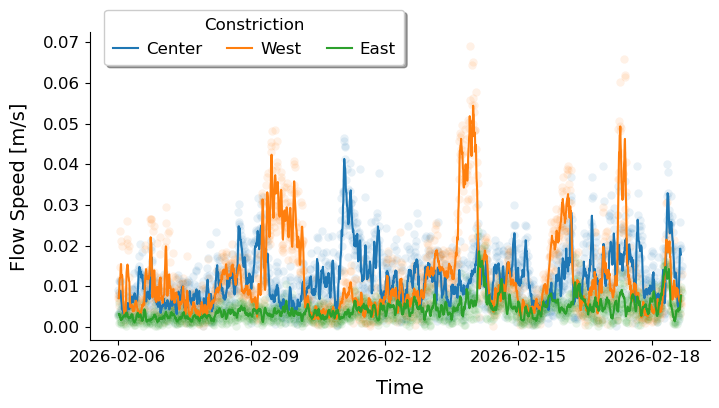

In [18]:
t0 = None
tf = speed_e.time.values[-1]

sc_sel = speed_c.sel(time=slice(t0, tf))
sw_sel = speed_w.sel(time=slice(t0, tf))
se_sel = speed_e.sel(time=slice(t0, tf))

sc_ra_sel = sc_ra.sel(time=slice(t0, tf))
sw_ra_sel = sw_ra.sel(time=slice(t0, tf))
se_ra_sel = se_ra.sel(time=slice(t0, tf))

fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(x=sc_sel.time, y=sc_sel, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=sw_sel.time, y=sw_sel, alpha=0.1, color='tab:orange', ax=ax)
sns.scatterplot(x=se_sel.time, y=se_sel, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=sc_ra_sel.time, y=sc_ra_sel, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=sw_ra_sel.time, y=sw_ra_sel, label='West', color='tab:orange', ax=ax)
sns.lineplot(x=se_ra_sel.time, y=se_ra_sel, label='East', color='tab:green', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=3, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0.01, 1.1),
          handlelength=1.5, handletextpad=0.5, columnspacing=1.5, borderpad=0.5)

plt.show()

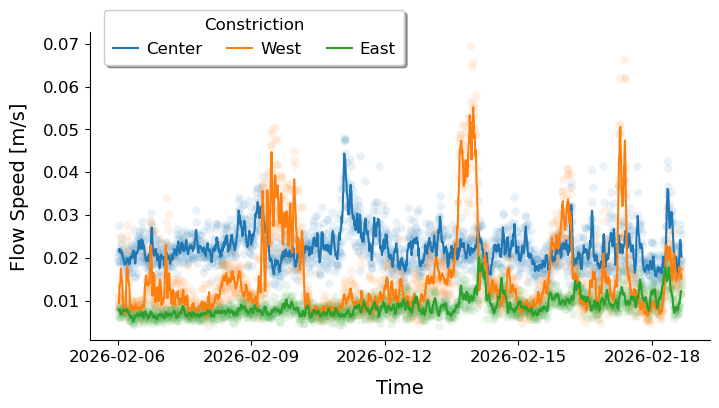

In [7]:
t0 = None
tf = speed_e.time.values[-1]

sc_sel = speed_c.sel(time=slice(t0, tf))
sw_sel = speed_w.sel(time=slice(t0, tf))
se_sel = speed_e.sel(time=slice(t0, tf))

sc_ra_sel = sc_ra.sel(time=slice(t0, tf))
sw_ra_sel = sw_ra.sel(time=slice(t0, tf))
se_ra_sel = se_ra.sel(time=slice(t0, tf))

fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(x=sc_sel.time, y=sc_sel, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=sw_sel.time, y=sw_sel, alpha=0.1, color='tab:orange', ax=ax)
sns.scatterplot(x=se_sel.time, y=se_sel, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=sc_ra_sel.time, y=sc_ra_sel, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=sw_ra_sel.time, y=sw_ra_sel, label='West', color='tab:orange', ax=ax)
sns.lineplot(x=se_ra_sel.time, y=se_ra_sel, label='East', color='tab:green', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=3, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0.01, 1.1),
          handlelength=1.5, handletextpad=0.5, columnspacing=1.5, borderpad=0.5)

plt.show()

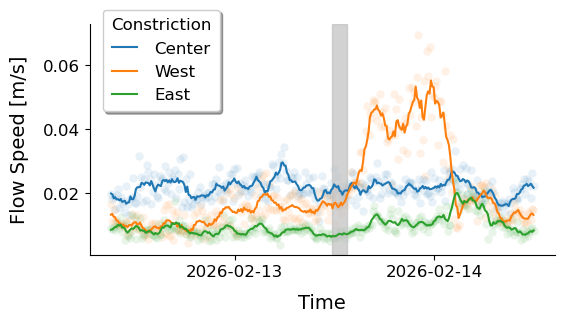

In [8]:
t0 = '2026-02-12 09:00:00'
tf = '2026-02-14 12:00:00'

sc_sel = speed_c.sel(time=slice(t0, tf))
sw_sel = speed_w.sel(time=slice(t0, tf))
se_sel = speed_e.sel(time=slice(t0, tf))

sc_ra_sel = sc_ra.sel(time=slice(t0, tf))
sw_ra_sel = sw_ra.sel(time=slice(t0, tf))
se_ra_sel = se_ra.sel(time=slice(t0, tf))

fig, ax = plt.subplots(figsize=(6, 3))

sns.scatterplot(x=sc_sel.time, y=sc_sel, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=sw_sel.time, y=sw_sel, alpha=0.1, color='tab:orange', ax=ax)
sns.scatterplot(x=se_sel.time, y=se_sel, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=sc_ra_sel.time, y=sc_ra_sel, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=sw_ra_sel.time, y=sw_ra_sel, label='West', color='tab:orange', ax=ax)
sns.lineplot(x=se_ra_sel.time, y=se_ra_sel, label='East', color='tab:green', ax=ax)

ax.axvspan(pd.to_datetime('2026-02-13 11:45:00'), pd.to_datetime('2026-02-13 13:30:00'), color='silver', alpha=0.7)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=1, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0.01, 1.1),
          handlelength=1.5, handletextpad=1, borderpad=0.5)

plt.show()

### LZC v. LZE

In [ ]:
lake = 'Zug'
year = '2026'
date = '20260114'

loc_c = 'LZC'
sid_c = '16549'

loc_e = 'LZE'
sid_e = '16576'

In [ ]:
areader = ewg.adcp_reader.ADCPReader(lake, year, date, loc_c, sid_c)
ds_c = areader.load()

areader = ewg.adcp_reader.ADCPReader(lake, year, date, loc_e, sid_e)
ds_e = areader.load()

In [ ]:
deploy = pd.to_datetime('2025-10-31')
t_start = deploy + pd.Timedelta(days=1)
t_end = ds_e.time.values[-1]  # LZE battery died

z_max = 124
z_min = 113

ds_c = ds_c.sel(time=slice(t_start, t_end), depth=slice(z_max, z_min))
ds_e = ds_e.sel(time=slice(t_start, t_end), depth=slice(z_max, z_min))

In [ ]:
# shared time axis as mean of each instruments times
#time_shared = np.mean([ds_e.time.values.astype('int64'), ds_c.time.values.astype('int64')], axis=0).astype('datetime64[ns]')
#ds_c = ds_c.assign_coords(time=time_shared)
#ds_e = ds_e.assign_coords(time=time_shared)

uc = ds_c.vel.sel(dir='E')
vc = ds_c.vel.sel(dir='N')
speed_c = np.sqrt(uc**2 + vc**2).mean(dim='depth')

ue = ds_e.vel.sel(dir='E')
ve = ds_e.vel.sel(dir='N')
speed_e = np.sqrt(ue**2 + ve**2).mean(dim='depth')

# 1-hour rolling average
sc_ra = speed_c.rolling(time=6, center=True).mean()
se_ra = speed_e.rolling(time=6, center=True).mean()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.scatterplot(x=speed_c.time, y=speed_c, alpha=0.1, color='tab:blue', ax=ax)
sns.scatterplot(x=speed_e.time, y=speed_e, alpha=0.1, color='tab:green', ax=ax)

sns.lineplot(x=sc_ra.time, y=sc_ra, label='Center', color='tab:blue', ax=ax)
sns.lineplot(x=se_ra.time, y=se_ra, label='East', color='tab:green', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.legend(ncols=2, title='Constriction', fontsize=12, title_fontsize=12, shadow=True, fancybox=True, loc='upper left', bbox_to_anchor=(0, 1.1))

plt.show()